In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

In [2]:
path = Path("../data/es_dollar_bars.csv")
if not path.exists():
    raise FileNotFoundError("es_dollar_bars.csv not found.")

bars = pd.read_csv(path, parse_dates=["timestamp"])
bars = bars.sort_values("timestamp").reset_index(drop=True)
close = bars.set_index("timestamp")["close"].sort_index()

print("Start:", close.index.min())
print("End:", close.index.max())
print("Bars:", len(close))

Start: 2013-09-01 17:19:56.232000
End: 2013-09-03 13:49:06.359000
Bars: 149


In [3]:
WINDOW = 20
NUM_STD = 2

bb = pd.DataFrame(index=close.index)
bb["close"] = close
bb["mid"] = close.rolling(WINDOW).mean()
bb["std"] = close.rolling(WINDOW).std()
bb["upper"] = bb["mid"] + NUM_STD * bb["std"]
bb["lower"] = bb["mid"] - NUM_STD * bb["std"]
bb = bb.dropna()

display(bb.head())

,close,mid,std,upper,lower
timestamp,,,,,
2013-09-03 02:25:43.889,1647.00,1645.400,2.296164,1649.992328,1640.807672
2013-09-03 02:58:19.615,1648.00,1645.775,2.053399,1649.881798,1641.668202
2013-09-03 03:42:24.044,1647.75,1646.125,1.721574,1649.568147,1642.681853
2013-09-03 03:54:27.751,1643.50,1646.175,1.622417,1649.419834,1642.930166
2013-09-03 03:56:44.113,1643.50,1646.200,1.574049,1649.348099,1643.051901


In [4]:
bb["side"] = 0
bb.loc[bb["close"] < bb["lower"], "side"] = 1
bb.loc[bb["close"] > bb["upper"], "side"] = -1

signal_events = bb.index[bb["side"] != 0]

print("Signal events:", len(signal_events))
print("Long signals:", (bb.loc[signal_events, "side"] == 1).sum())
print("Short signals:", (bb.loc[signal_events, "side"] == -1).sum())

Signal events: 17
Long signals: 17
Short signals: 0


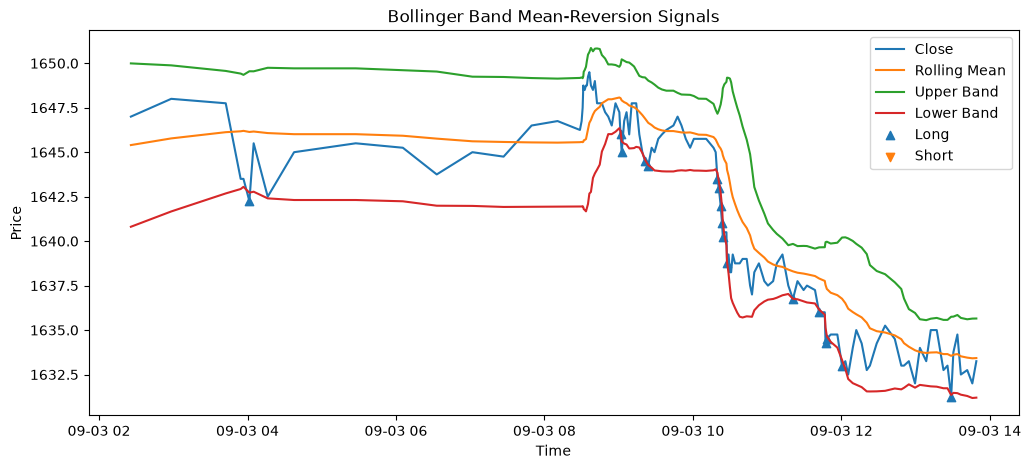

In [5]:
plt.figure(figsize=(12,5))
plt.plot(bb.index, bb["close"], label="Close")
plt.plot(bb.index, bb["mid"], label="Rolling Mean")
plt.plot(bb.index, bb["upper"], label="Upper Band")
plt.plot(bb.index, bb["lower"], label="Lower Band")

long_idx = bb.index[bb["side"] == 1]
short_idx = bb.index[bb["side"] == -1]

plt.scatter(long_idx, bb.loc[long_idx, "close"], marker="^", label="Long")
plt.scatter(short_idx, bb.loc[short_idx, "close"], marker="v", label="Short")

plt.title("Bollinger Band Mean-Reversion Signals")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [6]:
def get_daily_vol(close, span=100):
    idx = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    idx = idx[idx > 0]

    prev_idx = pd.Series(
        close.index[idx - 1],
        index=close.index[close.shape[0] - idx.shape[0]:]
    )

    daily_ret = close.loc[prev_idx.index].values / close.loc[prev_idx.values].values - 1
    daily_ret = pd.Series(daily_ret, index=prev_idx.index)

    return daily_ret.ewm(span=span).std()

daily_vol = get_daily_vol(close)

In [7]:
def add_vertical_barrier(t_events, close, num_hours=1):
    positions = close.index.searchsorted(
        t_events + pd.Timedelta(hours=num_hours)
    )

    valid = positions < len(close)
    positions = positions[valid]
    valid_events = t_events[valid]

    return pd.Series(close.index[positions], index=valid_events)

t1 = add_vertical_barrier(signal_events, close, num_hours=1)

print("Valid vertical barriers:", len(t1))

Valid vertical barriers: 16


In [8]:
side = bb["side"].reindex(signal_events)
trgt = daily_vol.reindex(signal_events, method="ffill").dropna()

common_events = (
    signal_events
    .intersection(t1.index)
    .intersection(trgt.index)
)

side = side.loc[common_events]
trgt = trgt.loc[common_events]
t1 = t1.loc[common_events]

print("Usable events:", len(common_events))

Usable events: 16


In [9]:
def apply_triple_barrier_meta(close, t_events, t1, trgt, side, pt_sl=(0,2)):
    records = []

    for t0 in t_events:
        end = t1.loc[t0]
        target = trgt.loc[t0]
        trade_side = side.loc[t0]

        path = close.loc[t0:end]
        if len(path) < 2:
            continue

        raw_ret = path / path.iloc[0] - 1
        side_ret = raw_ret * trade_side

        pt_touch = pd.NaT
        sl_touch = pd.NaT

        if pt_sl[0] > 0:
            hit = side_ret[side_ret > pt_sl[0] * target]
            if not hit.empty:
                pt_touch = hit.index[0]

        if pt_sl[1] > 0:
            hit = side_ret[side_ret < -pt_sl[1] * target]
            if not hit.empty:
                sl_touch = hit.index[0]

        candidates = [end]
        if pd.notna(pt_touch):
            candidates.append(pt_touch)
        if pd.notna(sl_touch):
            candidates.append(sl_touch)

        first_touch = min(candidates)

        if pd.notna(sl_touch) and first_touch == sl_touch:
            barrier = "sl"
        elif pd.notna(pt_touch) and first_touch == pt_touch:
            barrier = "pt"
        else:
            barrier = "vertical"

        records.append({
            "t0": t0,
            "t1": first_touch,
            "trgt": target,
            "side": trade_side,
            "first_barrier": barrier
        })

    if not records:
        return pd.DataFrame(columns=["t1","trgt","side","first_barrier"])

    return pd.DataFrame(records).set_index("t0")

events = apply_triple_barrier_meta(
    close=close,
    t_events=common_events,
    t1=t1,
    trgt=trgt,
    side=side,
    pt_sl=(0,2)
)

print("Events:", len(events))
display(events.head())
if not events.empty:
    display(events["first_barrier"].value_counts())

Events: 16


,t1,trgt,side,first_barrier
t0,,,,
2013-09-03 04:01:30.460,2013-09-03 05:27:28.366,0.002191,1,vertical
2013-09-03 09:01:30.748,2013-09-03 10:04:34.458,0.001374,1,vertical
2013-09-03 09:02:26.499,2013-09-03 10:04:34.458,0.001358,1,vertical
2013-09-03 09:21:22.055,2013-09-03 10:22:27.062,0.001227,1,vertical
2013-09-03 09:23:54.553,2013-09-03 10:24:11.779,0.001228,1,vertical


first_barrier
vertical    13
sl           3
Name: count, dtype: int64

In [10]:
def get_meta_labels(events, close):
    if events.empty:
        return pd.DataFrame(columns=["ret","bin"])

    out = pd.DataFrame(index=events.index)

    raw_ret = pd.Series(
        [
            close.loc[row["t1"]] / close.loc[t0] - 1
            for t0, row in events.iterrows()
        ],
        index=events.index
    )

    out["ret"] = raw_ret * events["side"]
    out["bin"] = (out["ret"] > 0).astype(int)

    return out

meta_labels = get_meta_labels(events, close)
events = events.join(meta_labels)

print("Meta-label distribution:")
if not events.empty:
    display(events["bin"].value_counts().sort_index())

Meta-label distribution:


bin
0    13
1     3
Name: count, dtype: int64

In [11]:
feature_frame = pd.DataFrame(index=close.index)

log_ret = np.log(close).diff()

feature_frame["volatility"] = log_ret.rolling(10).std()

feature_frame["serial_corr"] = (
    log_ret.rolling(20)
    .apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)
)

fast_ma = close.rolling(10).mean()
slow_ma = close.rolling(30).mean()
feature_frame["ma_distance"] = fast_ma / slow_ma - 1

bb_mid = close.rolling(WINDOW).mean()
bb_std = close.rolling(WINDOW).std()
feature_frame["bb_distance"] = (close - bb_mid) / bb_std

feature_frame = feature_frame.reindex(events.index)
feature_frame["side"] = events["side"]
feature_frame["target_vol"] = events["trgt"]

dataset = feature_frame.join(events["bin"].rename("label")).dropna()

display(dataset.head())
print("Dataset size:", len(dataset))

,volatility,serial_corr,ma_distance,bb_distance,side,target_vol,label
t0,,,,,,,
2013-09-03 09:01:30.748,0.000458,-0.042938,0.000116,-2.175931,1,0.001374,0
2013-09-03 09:02:26.499,0.000448,-0.046540,-0.000126,-2.524740,1,0.001358,1
2013-09-03 09:21:22.055,0.000731,-0.112518,-0.000673,-2.063525,1,0.001227,0
2013-09-03 09:23:54.553,0.000709,-0.073801,-0.000653,-2.020787,1,0.001228,0
2013-09-03 10:19:51.389,0.000364,0.344857,-0.000258,-2.406341,1,0.001175,0


Dataset size: 15


In [12]:
if len(dataset) == 0:
    print("No observations available.")
else:
    y_primary = dataset["label"]
    primary_pred = np.ones(len(y_primary), dtype=int)

    print(f"Primary Accuracy:  {accuracy_score(y_primary, primary_pred):.3f}")
    print(f"Primary Precision: {precision_score(y_primary, primary_pred, zero_division=0):.3f}")
    print(f"Primary Recall:    {recall_score(y_primary, primary_pred, zero_division=0):.3f}")
    print(f"Primary F1:        {f1_score(y_primary, primary_pred, zero_division=0):.3f}")

Primary Accuracy:  0.133
Primary Precision: 0.133
Primary Recall:    1.000
Primary F1:        0.235


In [13]:
feature_cols = [
    "volatility",
    "serial_corr",
    "ma_distance",
    "bb_distance",
    "target_vol",
    "side"
]

split = int(len(dataset) * 0.70)

train = dataset.iloc[:split]
test = dataset.iloc[split:]

X_train = train[feature_cols]
y_train = train["label"]

X_test = test[feature_cols]
y_test = test["label"]

print("Train size:", len(train))
print("Test size:", len(test))
print()
print("Train labels:")
print(y_train.value_counts())
print()
print("Test labels:")
print(y_test.value_counts())

Train size: 10
Test size: 5

Train labels:
label
0    9
1    1
Name: count, dtype: int64

Test labels:
label
0    4
1    1
Name: count, dtype: int64


In [14]:
if len(dataset) < 10 or len(train) == 0 or y_train.nunique() < 2:
    print("Not enough observations/classes for a meaningful Random Forest.")
    model = None
else:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=3,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)
    print("Random Forest trained.")

Random Forest trained.


In [15]:
if model is not None and len(X_test) > 0:
    pred = model.predict(X_test)

    print(f"Secondary Accuracy:  {accuracy_score(y_test, pred):.3f}")
    print(f"Secondary Precision: {precision_score(y_test, pred, zero_division=0):.3f}")
    print(f"Secondary Recall:    {recall_score(y_test, pred, zero_division=0):.3f}")
    print(f"Secondary F1:        {f1_score(y_test, pred, zero_division=0):.3f}")
    print()
    print(classification_report(y_test, pred, zero_division=0))
else:
    print("Secondary-model evaluation skipped.")

Secondary Accuracy:  0.400
Secondary Precision: 0.250
Secondary Recall:    1.000
Secondary F1:        0.400

              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       0.25      1.00      0.40         1

    accuracy                           0.40         5
   macro avg       0.62      0.62      0.40         5
weighted avg       0.85      0.40      0.40         5



In [16]:
if model is not None and len(X_test) > 0:
    cm = confusion_matrix(y_test, pred, labels=[0,1])

    cm_df = pd.DataFrame(
        cm,
        index=["Actual Pass","Actual Trade"],
        columns=["Predicted Pass","Predicted Trade"]
    )

    display(cm_df)

,Predicted Pass,Predicted Trade
Actual Pass,1,3
Actual Trade,0,1


volatility     0.250000
target_vol     0.214286
ma_distance    0.196429
serial_corr    0.178571
bb_distance    0.160714
side           0.000000
dtype: float64

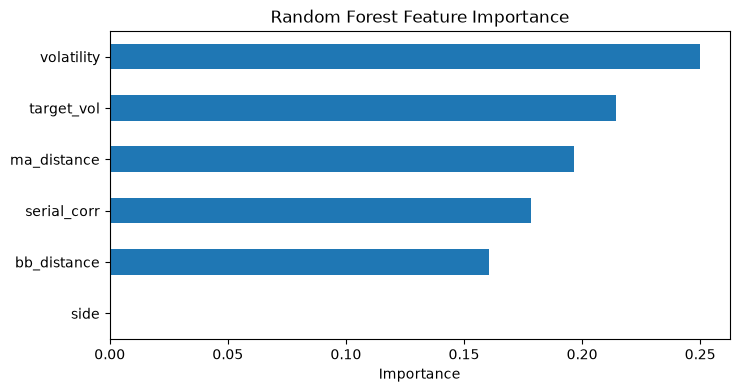

In [17]:
if model is not None:
    importance = pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

    display(importance)

    plt.figure(figsize=(8,4))
    importance.sort_values().plot(kind="barh")
    plt.title("Random Forest Feature Importance")
    plt.xlabel("Importance")
    plt.show()